# Experiments 13\u201315: Presentation Slides

Text prefixes condition KV caches \u2192 learned soft prompts leapfrog text \u2192
cross-dataset transfer reveals structure \u2192 routing exploits that structure.

**Slides:**
1. Every Prefix Helps \u2014 Even Noise
2. 245K Parameters Buy 2\u00d7 the Best Text
3. Random Init Wins \u2014 Warm-Start Is a Trap
4. BoolQ Poisons, GSM8K Absorbs Everything
5. Routing Closes 30% of the Oracle Gap

In [1]:
import os
os.umask(0o000)
import sys
sys.path.insert(0, "../../..")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
import seaborn as sns
from pathlib import Path
from scipy import stats

from lib.analysis import cohens_d, win_rate, paired_ttest

# --- Seaborn theme (matches Exp 13/14) ---
sns.set_theme(style='whitegrid', context='notebook', font_scale=1.05,
              rc={
                  'figure.dpi': 150,
                  'savefig.dpi': 150,
                  'savefig.bbox': 'tight',
                  'font.family': 'sans-serif',
                  'axes.edgecolor': '.8',
                  'axes.linewidth': 0.6,
                  'grid.color': '.92',
                  'grid.linewidth': 0.5,
                  'grid.alpha': 0.7,
                  'patch.edgecolor': 'white',
                  'patch.linewidth': 0.6,
                  'xtick.major.width': 0.6,
                  'ytick.major.width': 0.6,
                  'xtick.color': '.4',
                  'ytick.color': '.4',
                  'axes.titleweight': 'medium',
                  'axes.labelweight': 'normal',
                  'axes.titlesize': 13,
                  'axes.labelsize': 11,
                  'axes.titlepad': 10,
                  'legend.framealpha': 0.9,
                  'legend.edgecolor': '.85',
                  'legend.fontsize': 10,
              })

# --- Paths ---
EXP14_DIR = Path("../../../results/decoder_only/exp14")
EXP15_DIR = Path("../../../results/decoder_only/exp15")
CHART_DIR = EXP15_DIR / "charts"
CHART_DIR.mkdir(exist_ok=True, mode=0o777)

# --- Load data ---
exp14_summary = json.loads((EXP14_DIR / "summary.json").read_text())
exp14_results = json.loads((EXP14_DIR / "results.json").read_text())
transfer = json.loads((EXP14_DIR / "transfer_matrix.json").read_text())
exp15_summary = json.loads((EXP15_DIR / "summary.json").read_text())

print(f"Exp14 summary: {len(exp14_summary['rankings'])} ranked conditions")
print(f"Exp14 transfer: {len(transfer['per_pair'])} pairs")
print(f"Exp15 summary: {len(exp15_summary['results'])} routing results")

# --- Shared constants ---
DATASETS = ['ms_marco', 'squad_v2', 'triviaqa', 'hotpotqa', 'drop', 'boolq', 'gsm8k']
DS_LABELS = {
    'ms_marco': 'MS MARCO', 'squad_v2': 'SQuAD 2.0', 'triviaqa': 'TriviaQA',
    'hotpotqa': 'HotpotQA', 'drop': 'DROP', 'boolq': 'BoolQ', 'gsm8k': 'GSM8K',
}
INIT_NAMES = ['warm_comprehend', 'warm_extract', 'warm_classify', 'rand']
INIT_LABELS = {
    'warm_comprehend': 'Warm: comprehend',
    'warm_extract': 'Warm: extract',
    'warm_classify': 'Warm: classify',
    'rand': 'Random init',
}

# --- Color palette ---
GROUP_COLORS = {
    'structural':  {'bar': '#D9DCE0', 'accent': '#A0A7B1'},
    'keywords':    {'bar': '#EDE0CA', 'accent': '#C8AE82'},
    'instruction': {'bar': '#CADAEE', 'accent': '#8DB3D0'},
    'query':       {'bar': '#C4E5DC', 'accent': '#84C4B6'},
    'soft':        {'bar': '#D8B4FE', 'accent': '#A855F7'},
    'universal':   {'bar': '#FDE68A', 'accent': '#D97706'},
}
EXP13_COND_GROUP = {
    'repeat_token': 'structural', 'random': 'structural',
    'unrelated': 'structural', 'adversarial': 'structural',
    'tfidf': 'keywords', 'scrambled_comprehend': 'keywords',
    'extract': 'instruction', 'classify': 'instruction', 'comprehend': 'instruction',
    'oracle': 'query', 'llm_question': 'query',
    'ood_query': 'query', 'misleading_query': 'query',
}
INIT_COLORS = {
    'warm_comprehend': '#3B82F6',
    'warm_extract': '#10B981',
    'warm_classify': '#F59E0B',
    'rand': '#A855F7',
}
COND_LABELS = {
    'comprehend': 'Comprehend', 'extract': 'Extract', 'classify': 'Classify',
    'llm_question': 'LLM question', 'oracle': 'Oracle (query)',
    'tfidf': 'TF-IDF keywords', 'scrambled_comprehend': 'Scrambled comprehend',
    'unrelated': 'Unrelated text', 'adversarial': 'Adversarial',
    'random': 'Random tokens', 'repeat_token': 'Repeat token',
    'ood_query': 'OOD query', 'misleading_query': 'Misleading query',
    'soft_rand_nonorm': 'Soft: random init',
    'soft_warm_comprehend_nonorm': 'Soft: warm comprehend',
    'soft_warm_extract_nonorm': 'Soft: warm extract',
    'soft_warm_classify_nonorm': 'Soft: warm classify',
    'univ_rand_nonorm': 'Univ: random init',
    'univ_warm_comprehend_nonorm': 'Univ: warm comprehend',
    'univ_warm_extract_nonorm': 'Univ: warm extract',
    'univ_warm_classify_nonorm': 'Univ: warm classify',
}

def stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    return ''

# --- Build per-sample NLL arrays from results.json ---
per_sample = exp14_results['per_sample_results']
nll_arrays = {}
for ds_name in DATASETS:
    nll_arrays[ds_name] = {}
    samples = per_sample[ds_name]
    for key in samples[0]:
        if key.startswith('nll_'):
            vals = [s[key] for s in samples if key in s]
            if len(vals) == len(samples):
                nll_arrays[ds_name][key] = np.array(vals)

print(f"Charts will be saved to {CHART_DIR}")


Exp14 summary: 29 ranked conditions
Exp14 transfer: 56 pairs
Exp15 summary: 40 routing results
Charts will be saved to ../../../results/decoder_only/exp15/charts


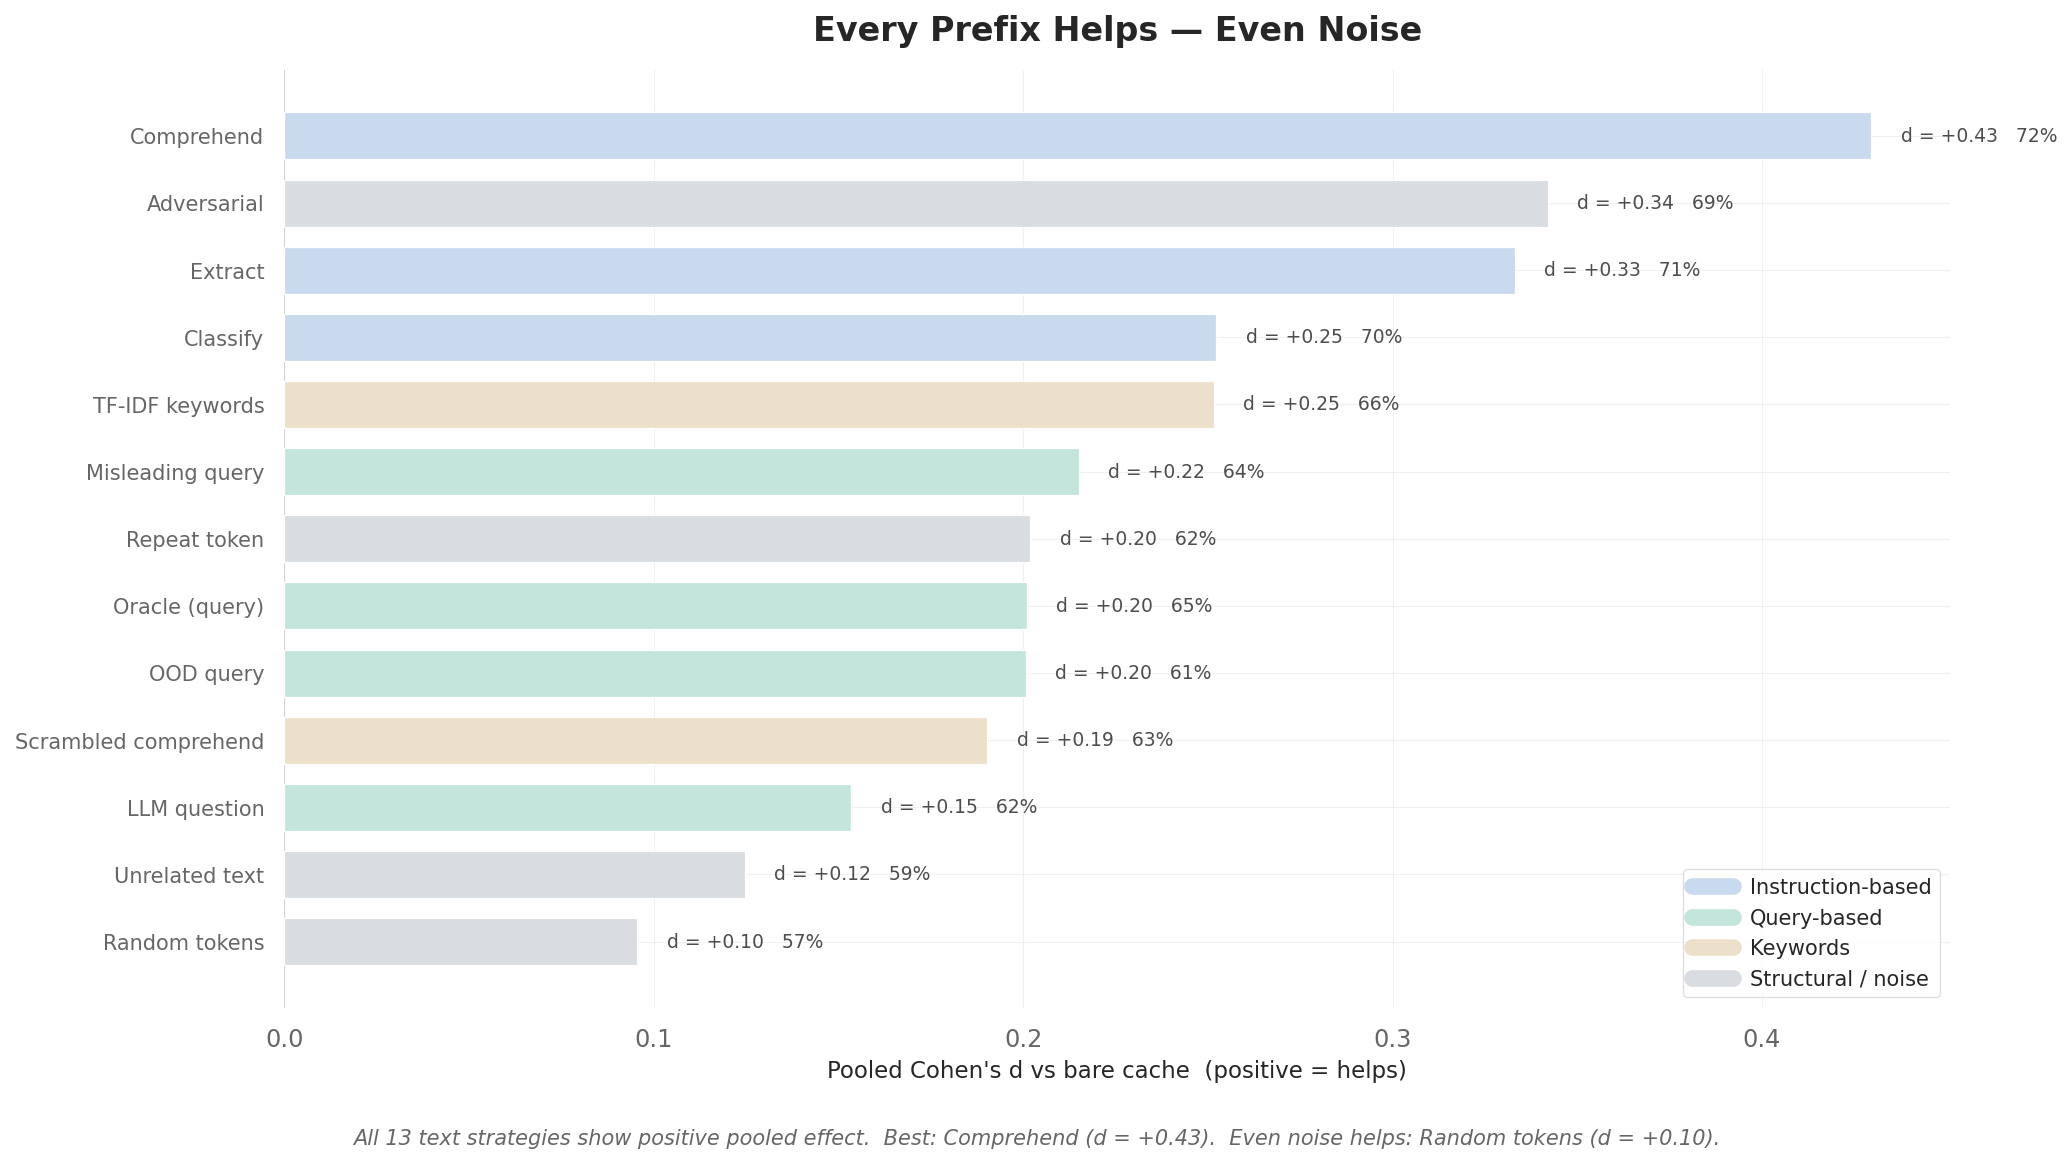

Saved slide_1_every_prefix_helps.png


In [2]:
# Slide 1: Every Prefix Helps - Even Noise
# Horizontal bar chart of 13 Exp13 conditions sorted by pooled Cohen's d
rankings = exp14_summary['rankings']
exp13_conds = [r for r in rankings if r['source'] == 'Exp13']
exp13_conds.sort(key=lambda r: r['pooled_d'])

labels = [COND_LABELS.get(r['condition'], r['condition']) for r in exp13_conds]
d_vals = [r['pooled_d'] for r in exp13_conds]
win_vals = [r['pooled_win'] for r in exp13_conds]

def get_exp13_color(cond):
    grp = EXP13_COND_GROUP.get(cond, 'structural')
    return GROUP_COLORS[grp]['bar']

colors = [get_exp13_color(r['condition']) for r in exp13_conds]

fig, ax = plt.subplots(figsize=(14, 7.5))
y_pos = np.arange(len(exp13_conds))
ax.barh(y_pos, d_vals, color=colors, edgecolor='white', linewidth=0.6, height=0.7)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.axvline(0, color='.6', linewidth=0.5, zorder=0)
sns.despine(left=True, bottom=True)

# Annotations with d and win rate
for i, r in enumerate(exp13_conds):
    d = r['pooled_d']
    w = r['pooled_win']
    x_text = max(d, 0) + 0.008
    ax.text(x_text, i, f"d = {d:+.2f}   {w:.0%}",
            va='center', ha='left', fontsize=9, color='.3')

# Legend by group
legend_elements = [
    Line2D([0], [0], color=GROUP_COLORS['instruction']['bar'], lw=8, label='Instruction-based'),
    Line2D([0], [0], color=GROUP_COLORS['query']['bar'], lw=8, label='Query-based'),
    Line2D([0], [0], color=GROUP_COLORS['keywords']['bar'], lw=8, label='Keywords'),
    Line2D([0], [0], color=GROUP_COLORS['structural']['bar'], lw=8, label='Structural / noise'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10, framealpha=0.9)

ax.set_xlabel("Pooled Cohen's d vs bare cache  (positive = helps)", fontsize=11)
ax.set_ylabel('')
ax.set_title('Every Prefix Helps \u2014 Even Noise', fontsize=16, fontweight='bold', pad=14)

# Takeaway callout — placed below xlabel with extra spacing
best = exp13_conds[-1]
worst = exp13_conds[0]
fig.text(0.5, -0.03,
         f'All 13 text strategies show positive pooled effect.  '
         f'Best: {COND_LABELS[best["condition"]]} (d = {best["pooled_d"]:+.2f}).  '
         f'Even noise helps: {COND_LABELS[worst["condition"]]} (d = {worst["pooled_d"]:+.2f}).',
         ha='center', fontsize=10, color='.4', style='italic')

fig.tight_layout()
fig.savefig(CHART_DIR / 'slide_1_every_prefix_helps.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("Saved slide_1_every_prefix_helps.png")


/var/tmp/ipykernel_1958039/497928167.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


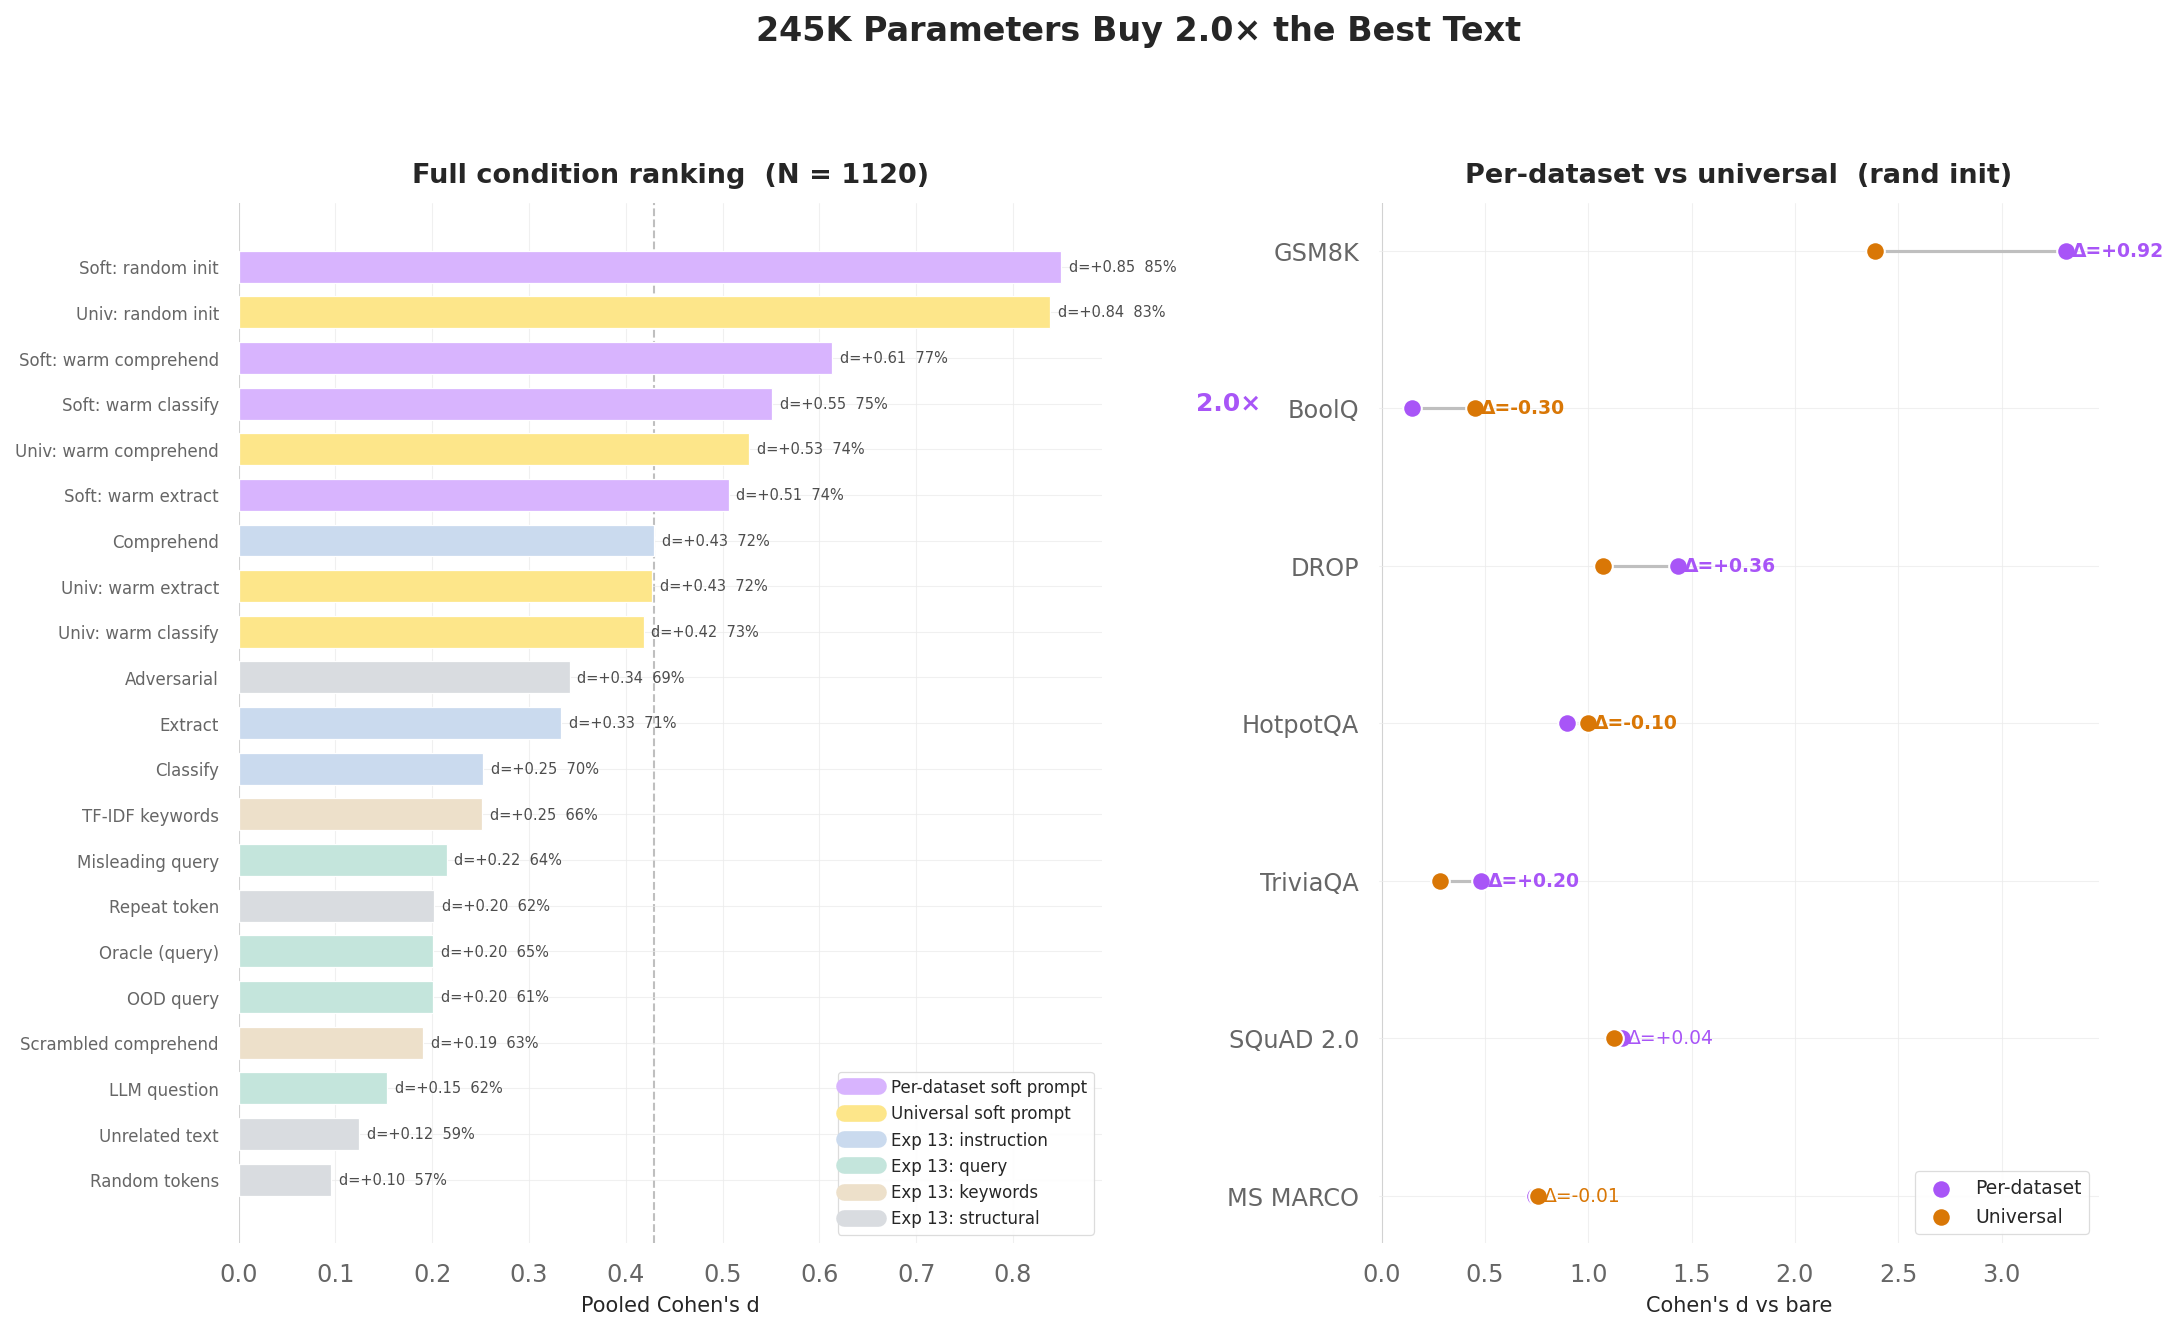

Saved slide_2_soft_prompt_ranking.png


In [3]:
# Slide 2: 245K Parameters Buy 2x the Best Text
# Left: unified ranking of ~21 conditions
# Right: per-dataset dumbbell (per-dataset vs universal soft prompt)
rankings = exp14_summary['rankings']

# Filter: nonorm soft/univ + all Exp13 (same logic as Exp 14 charts)
filtered = []
seen_base = set()
for r in rankings:
    cond = r['condition']
    if r['source'] == 'Exp13':
        filtered.append(r)
    elif cond.endswith('_nonorm'):
        filtered.append(r)
        seen_base.add(cond.replace('_nonorm', ''))
    elif cond not in seen_base:
        nonorm_exists = any(r2['condition'] == cond + '_nonorm' for r2 in rankings)
        if not nonorm_exists:
            filtered.append(r)

filtered.sort(key=lambda r: r['pooled_d'])

def get_bar_color(r):
    if r['source'] == 'Soft':
        return GROUP_COLORS['soft']['bar']
    elif r['source'] == 'Univ':
        return GROUP_COLORS['universal']['bar']
    else:
        grp = EXP13_COND_GROUP.get(r['condition'], 'structural')
        return GROUP_COLORS[grp]['bar']

fig, (ax_rank, ax_db) = plt.subplots(1, 2, figsize=(16, 9),
                                      gridspec_kw={'width_ratios': [1.2, 1], 'wspace': 0.35})

# --- Left panel: unified ranking ---
f_labels = [COND_LABELS.get(r['condition'], r['condition']) for r in filtered]
f_colors = [get_bar_color(r) for r in filtered]
f_d = [r['pooled_d'] for r in filtered]
f_y = np.arange(len(filtered))

ax_rank.barh(f_y, f_d, color=f_colors, edgecolor='white', linewidth=0.6, height=0.7)
ax_rank.set_yticks(f_y)
ax_rank.set_yticklabels(f_labels, fontsize=8)
ax_rank.axvline(0, color='.6', linewidth=0.5, zorder=0)
sns.despine(ax=ax_rank, left=True, bottom=True)

for i, r in enumerate(filtered):
    d = r['pooled_d']
    w = r['pooled_win']
    x_text = max(d, 0) + 0.008
    ax_rank.text(x_text, i, f"d={d:+.2f}  {w:.0%}",
                 va='center', ha='left', fontsize=7, color='.3')

# "2x gain" annotation: reference line at best text + ratio label
best_text = max((r for r in filtered if r['source'] == 'Exp13'),
                key=lambda r: r['pooled_d'])
best_soft = max((r for r in filtered if r['source'] == 'Soft'),
                key=lambda r: r['pooled_d'])
ratio = best_soft['pooled_d'] / best_text['pooled_d'] if best_text['pooled_d'] > 0 else 0

ax_rank.axvline(best_text['pooled_d'], color='.75', linestyle='--', linewidth=1, zorder=0)

# Double-headed arrow bracket between best text and best soft
best_text_idx = filtered.index(best_text)
best_soft_idx = filtered.index(best_soft)
bx = max(f_d) + 0.12
ax_rank.annotate('', xy=(bx, best_text_idx), xytext=(bx, best_soft_idx),
                 arrowprops=dict(arrowstyle='<->', color=GROUP_COLORS['soft']['accent'],
                                 lw=1.5))
ax_rank.text(bx + 0.02, (best_text_idx + best_soft_idx) / 2,
             f'{ratio:.1f}\u00d7', fontsize=12, fontweight='bold',
             color=GROUP_COLORS['soft']['accent'], va='center', ha='left')

# Legend
legend_elements = [
    Line2D([0], [0], color=GROUP_COLORS['soft']['bar'], lw=8, label='Per-dataset soft prompt'),
    Line2D([0], [0], color=GROUP_COLORS['universal']['bar'], lw=8, label='Universal soft prompt'),
    Line2D([0], [0], color=GROUP_COLORS['instruction']['bar'], lw=8, label='Exp 13: instruction'),
    Line2D([0], [0], color=GROUP_COLORS['query']['bar'], lw=8, label='Exp 13: query'),
    Line2D([0], [0], color=GROUP_COLORS['keywords']['bar'], lw=8, label='Exp 13: keywords'),
    Line2D([0], [0], color=GROUP_COLORS['structural']['bar'], lw=8, label='Exp 13: structural'),
]
ax_rank.legend(handles=legend_elements, loc='lower right', fontsize=8, framealpha=0.9)
ax_rank.set_xlabel("Pooled Cohen's d", fontsize=10)
ax_rank.set_title('Full condition ranking  (N = 1120)', fontsize=13, fontweight='bold', pad=10)

# --- Right panel: per-dataset dumbbell ---
spec_rows = []
for ds_name in DATASETS:
    per_key = 'nll_soft_rand_nonorm'
    univ_key = 'nll_univ_rand_nonorm'
    if per_key in nll_arrays[ds_name] and univ_key in nll_arrays[ds_name]:
        diff_per = nll_arrays[ds_name]['nll_bare'] - nll_arrays[ds_name][per_key]
        diff_univ = nll_arrays[ds_name]['nll_bare'] - nll_arrays[ds_name][univ_key]
        d_per = cohens_d(diff_per)
        d_univ = cohens_d(diff_univ)
    else:
        d_per = 0.0
        d_univ = 0.0
    spec_rows.append({
        'Dataset': DS_LABELS[ds_name],
        'd_per': d_per,
        'd_univ': d_univ,
        'delta': d_per - d_univ,
    })

spec_df = pd.DataFrame(spec_rows)
y_db = np.arange(len(spec_df))

for i, row in spec_df.iterrows():
    ax_db.plot([row['d_per'], row['d_univ']], [i, i], color='.75', linewidth=1.5, zorder=1)

ax_db.scatter(spec_df['d_per'], y_db, s=80, color=GROUP_COLORS['soft']['accent'],
              zorder=3, label='Per-dataset', edgecolor='white', linewidth=1)
ax_db.scatter(spec_df['d_univ'], y_db, s=80, color=GROUP_COLORS['universal']['accent'],
              zorder=3, label='Universal', edgecolor='white', linewidth=1)

for i, row in spec_df.iterrows():
    d_max = max(row['d_per'], row['d_univ'])
    delta = row['delta']
    color = GROUP_COLORS['soft']['accent'] if delta > 0.01 else (
        GROUP_COLORS['universal']['accent'] if delta < -0.01 else '.5')
    ax_db.text(d_max + 0.03, i, f"\u0394={delta:+.2f}", va='center', ha='left',
               fontsize=9, color=color,
               fontweight='bold' if abs(delta) > 0.05 else 'normal')

ax_db.set_yticks(y_db)
ax_db.set_yticklabels(spec_df['Dataset'])
ax_db.axvline(0, color='.6', linewidth=0.5, zorder=0)
sns.despine(ax=ax_db, left=True, bottom=True)
ax_db.set_xlabel("Cohen's d vs bare", fontsize=10)
ax_db.set_title('Per-dataset vs universal  (rand init)', fontsize=13, fontweight='bold', pad=10)
ax_db.legend(fontsize=9, framealpha=0.9, loc='lower right')

fig.suptitle(f'245K Parameters Buy {ratio:.1f}\u00d7 the Best Text',
             fontsize=16, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(CHART_DIR / 'slide_2_soft_prompt_ranking.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("Saved slide_2_soft_prompt_ranking.png")


/var/tmp/ipykernel_1958039/2984067892.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


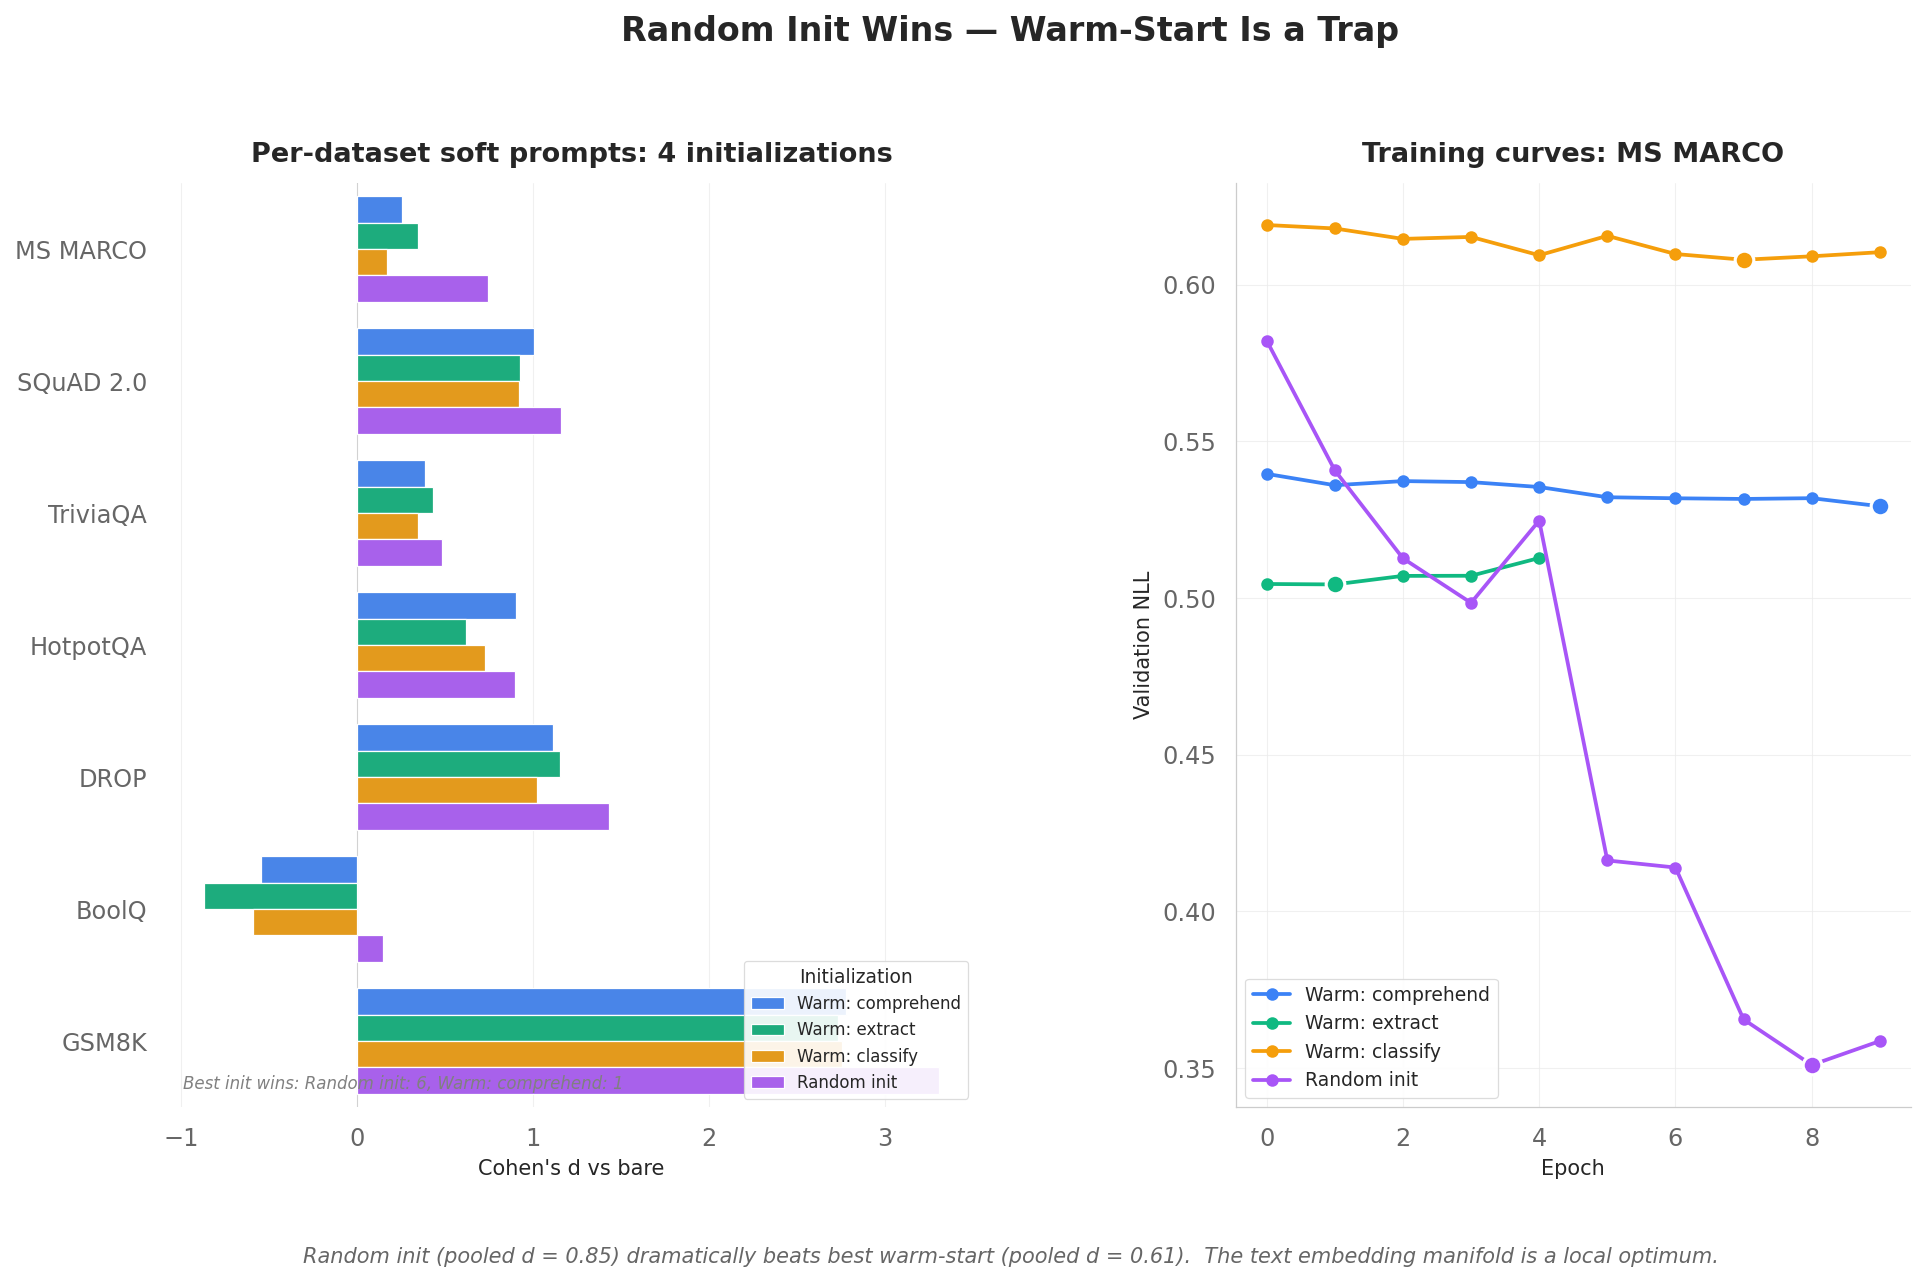

Saved slide_3_init_comparison.png


In [4]:
# Slide 3: Random Init Wins - Warm-Start Is a Trap
# Left: grouped horizontal bars (7 datasets x 4 inits)
# Right: MS MARCO training curves (val NLL vs epoch, 4 lines)

fig, (ax_bars, ax_curves) = plt.subplots(1, 2, figsize=(15, 8),
                                          gridspec_kw={'width_ratios': [1.2, 1], 'wspace': 0.35})

# --- Left panel: init comparison grouped bars ---
init_rows = []
for ds_name in DATASETS:
    for init_name in INIT_NAMES:
        nll_key = f'nll_soft_{init_name}_nonorm'
        if nll_key in nll_arrays[ds_name] and 'nll_bare' in nll_arrays[ds_name]:
            diff = nll_arrays[ds_name]['nll_bare'] - nll_arrays[ds_name][nll_key]
            d = cohens_d(diff)
        else:
            d = 0.0
        init_rows.append({
            'Dataset': DS_LABELS[ds_name],
            'Init': INIT_LABELS[init_name],
            'init_key': init_name,
            "Cohen's d": d,
        })

init_df = pd.DataFrame(init_rows)
init_palette = {INIT_LABELS[k]: v for k, v in INIT_COLORS.items()}
sns.barplot(data=init_df, y='Dataset', x="Cohen's d", hue='Init',
            palette=init_palette, ax=ax_bars, saturation=0.85,
            edgecolor='white', linewidth=0.6)

ax_bars.axvline(0, color='.6', linewidth=0.5, zorder=0)
sns.despine(ax=ax_bars, left=True, bottom=True)
ax_bars.set_xlabel("Cohen's d vs bare", fontsize=10)
ax_bars.set_ylabel('')
ax_bars.set_title('Per-dataset soft prompts: 4 initializations', fontsize=13,
                   fontweight='bold', pad=10)
ax_bars.legend(title='Initialization', fontsize=8, title_fontsize=9, framealpha=0.9,
               loc='lower right')

# Count wins per init
wins_by_init = {}
for ds_name in DATASETS:
    best_init = None
    best_d = -999
    for init_name in INIT_NAMES:
        sub = init_df[(init_df['Dataset'] == DS_LABELS[ds_name]) &
                      (init_df['init_key'] == init_name)]
        if len(sub) > 0:
            d_val = sub["Cohen's d"].values[0]
            if d_val > best_d:
                best_d = d_val
                best_init = init_name
    wins_by_init[best_init] = wins_by_init.get(best_init, 0) + 1

wins_text = ', '.join(f'{INIT_LABELS[k]}: {v}'
                      for k, v in sorted(wins_by_init.items(), key=lambda x: -x[1]))
ax_bars.text(0.02, 0.02, f'Best init wins: {wins_text}',
             transform=ax_bars.transAxes, fontsize=8, color='.5', style='italic')

# --- Right panel: MS MARCO training curves ---
training = exp14_summary['training_summary']
for init_name in INIT_NAMES:
    ts = training['ms_marco'][init_name]
    epochs = list(range(len(ts['val_losses'])))
    ax_curves.plot(epochs, ts['val_losses'], marker='o', markersize=5,
                   linewidth=1.8, color=INIT_COLORS[init_name],
                   label=INIT_LABELS[init_name])
    # Mark best epoch
    best_ep = ts['best_epoch']
    best_val = ts['best_val_nll']
    ax_curves.scatter([best_ep], [best_val], s=80, color=INIT_COLORS[init_name],
                      zorder=5, edgecolor='white', linewidth=1.5)

ax_curves.set_xlabel('Epoch', fontsize=10)
ax_curves.set_ylabel('Validation NLL', fontsize=10)
ax_curves.set_title('Training curves: MS MARCO', fontsize=13, fontweight='bold', pad=10)
ax_curves.legend(fontsize=9, framealpha=0.9)
sns.despine(ax=ax_curves)

# Pooled d from rankings for takeaway
rand_ranking = next((r for r in exp14_summary['rankings']
                     if r['condition'] == 'soft_rand_nonorm'), None)
rand_pooled = rand_ranking['pooled_d'] if rand_ranking else 0
warm_rankings = [r for r in exp14_summary['rankings']
                 if r['condition'] in ('soft_warm_comprehend_nonorm',
                                       'soft_warm_extract_nonorm',
                                       'soft_warm_classify_nonorm')]
best_warm_pooled = max((r['pooled_d'] for r in warm_rankings), default=0)

fig.suptitle('Random Init Wins \u2014 Warm-Start Is a Trap',
             fontsize=16, fontweight='bold', y=1.02)
fig.text(0.5, -0.02,
         f'Random init (pooled d = {rand_pooled:.2f}) dramatically beats '
         f'best warm-start (pooled d = {best_warm_pooled:.2f}).  '
         f'The text embedding manifold is a local optimum.',
         ha='center', fontsize=10, color='.4', style='italic')

fig.tight_layout()
fig.savefig(CHART_DIR / 'slide_3_init_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("Saved slide_3_init_comparison.png")


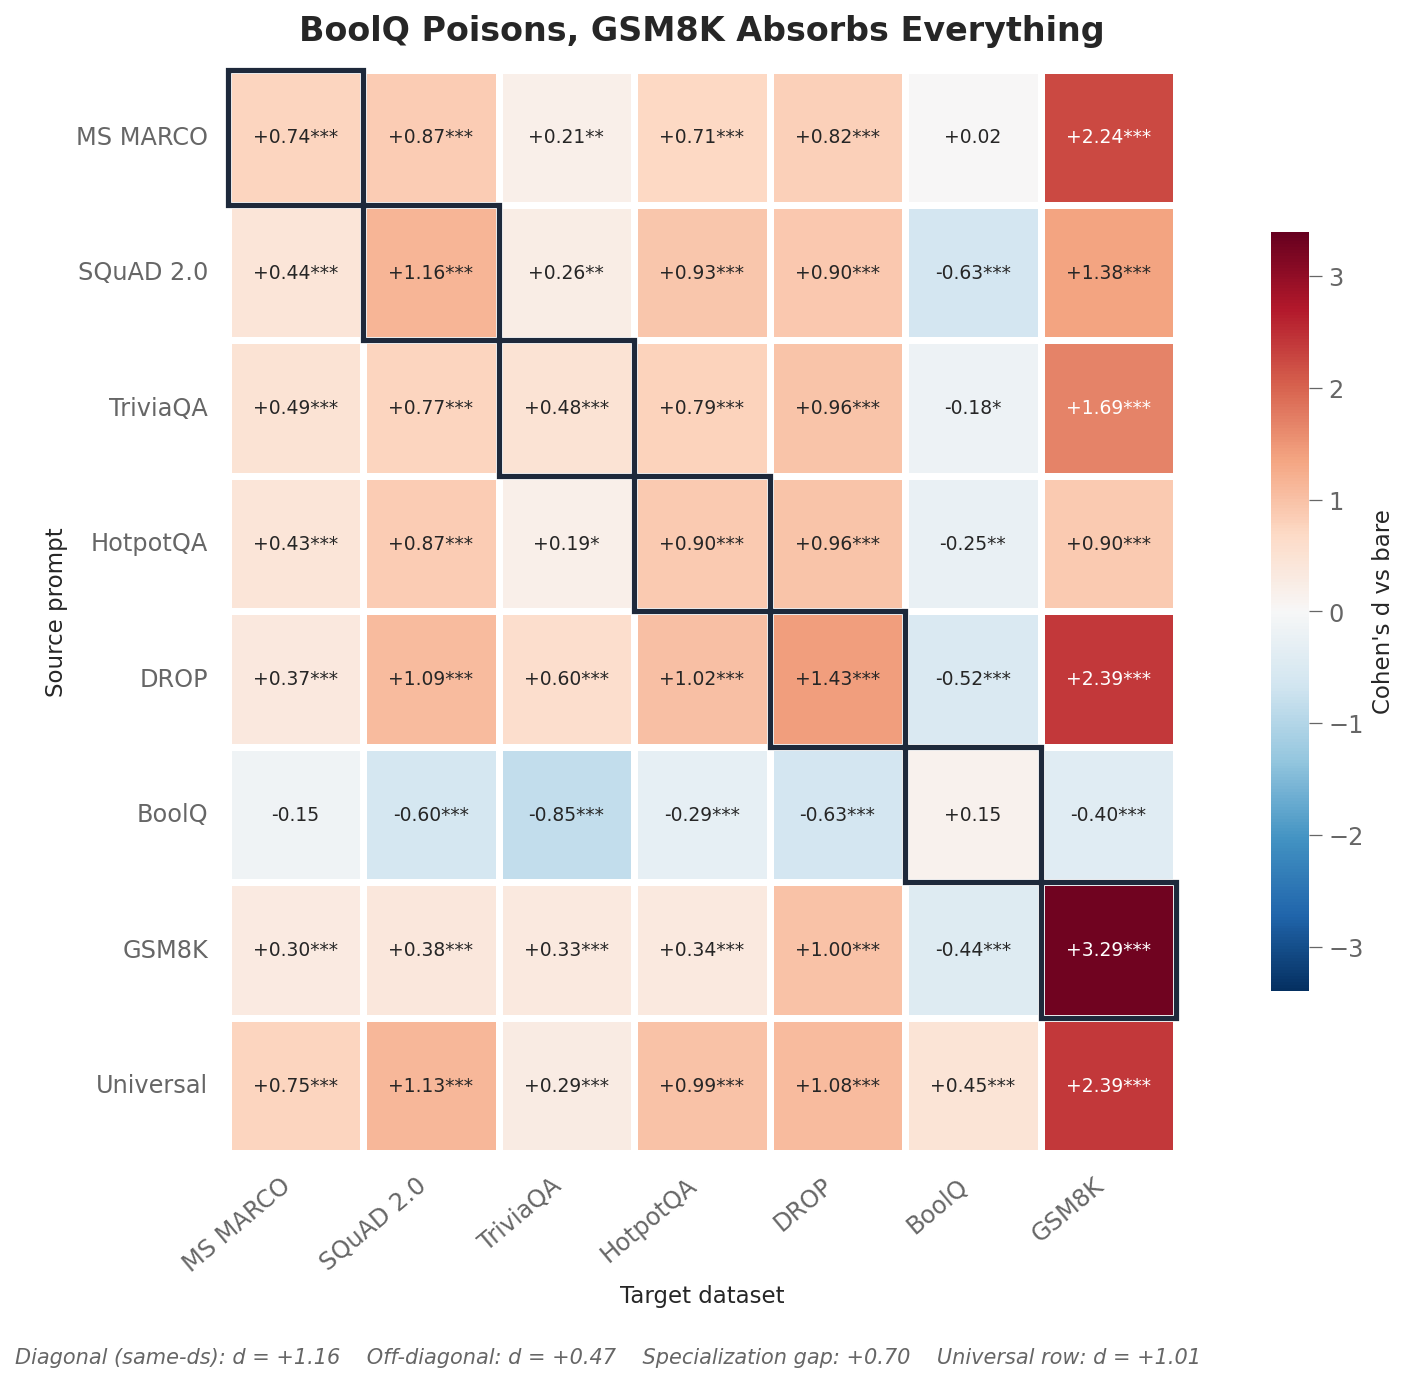

Diagonal mean: d = +1.164
Off-diagonal mean: d = +0.469
Universal mean: d = +1.011
Saved slide_4_transfer_matrix.png


In [5]:
# Slide 4: BoolQ Poisons, GSM8K Absorbs Everything
# Annotated 8x7 heatmap from cross-dataset transfer matrix
SOURCE_NAMES = DATASETS + ['universal']
SOURCE_LABELS = {**DS_LABELS, 'universal': 'Universal'}

# Build matrix from nested dicts
tm_data = []
tm_annot = []
for source in SOURCE_NAMES:
    row_d = []
    row_a = []
    for target in DATASETS:
        d = transfer['matrix_d'][source][target]
        p = transfer['matrix_p'][source][target]
        row_d.append(d)
        row_a.append(f"{d:+.2f}{stars(p)}")
    tm_data.append(row_d)
    tm_annot.append(row_a)

row_labels = [SOURCE_LABELS[s] for s in SOURCE_NAMES]
col_labels = [DS_LABELS[ds] for ds in DATASETS]

tm_matrix = pd.DataFrame(tm_data, index=row_labels, columns=col_labels)
tm_annot_df = pd.DataFrame(tm_annot, index=row_labels, columns=col_labels)

vabs = max(abs(tm_matrix.values.min()), abs(tm_matrix.values.max()))
tm_norm = TwoSlopeNorm(vcenter=0, vmin=-vabs - 0.1, vmax=vabs + 0.1)

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(tm_matrix, annot=tm_annot_df, fmt='', cmap='RdBu_r', norm=tm_norm,
            linewidths=2.5, linecolor='white', ax=ax, square=True,
            cbar_kws={'shrink': 0.7, 'label': "Cohen's d vs bare"},
            annot_kws={'fontsize': 9, 'fontweight': 'normal'})

ax.set_title('BoolQ Poisons, GSM8K Absorbs Everything',
             fontsize=16, fontweight='bold', pad=14)
ax.set_xlabel('Target dataset', fontsize=11)
ax.set_ylabel('Source prompt', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')

# Highlight diagonal (same-dataset, 7x7 portion only)
for i in range(len(DATASETS)):
    ax.add_patch(Rectangle((i, i), 1, 1, fill=False, edgecolor='#1E293B',
                            linewidth=2.5, clip_on=False))

# Summary stats
diag_vals = [tm_matrix.values[i, i] for i in range(len(DATASETS))]
off_diag_vals = [tm_matrix.values[i, j] for i in range(len(DATASETS))
                 for j in range(len(DATASETS)) if i != j]
univ_vals = tm_matrix.values[-1, :].tolist()
diag_mean = np.mean(diag_vals)
off_mean = np.mean(off_diag_vals)
univ_mean = np.mean(univ_vals)

stats_text = (f'Diagonal (same-ds): d = {diag_mean:+.2f}    '
              f'Off-diagonal: d = {off_mean:+.2f}    '
              f'Specialization gap: {diag_mean - off_mean:+.2f}    '
              f'Universal row: d = {univ_mean:+.2f}')
fig.text(0.5, -0.02, stats_text,
         ha='center', fontsize=10, color='.4', style='italic')

fig.tight_layout()
fig.savefig(CHART_DIR / 'slide_4_transfer_matrix.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f"Diagonal mean: d = {diag_mean:+.3f}")
print(f"Off-diagonal mean: d = {off_mean:+.3f}")
print(f"Universal mean: d = {univ_mean:+.3f}")
print("Saved slide_4_transfer_matrix.png")


/var/tmp/ipykernel_1958039/1125361003.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


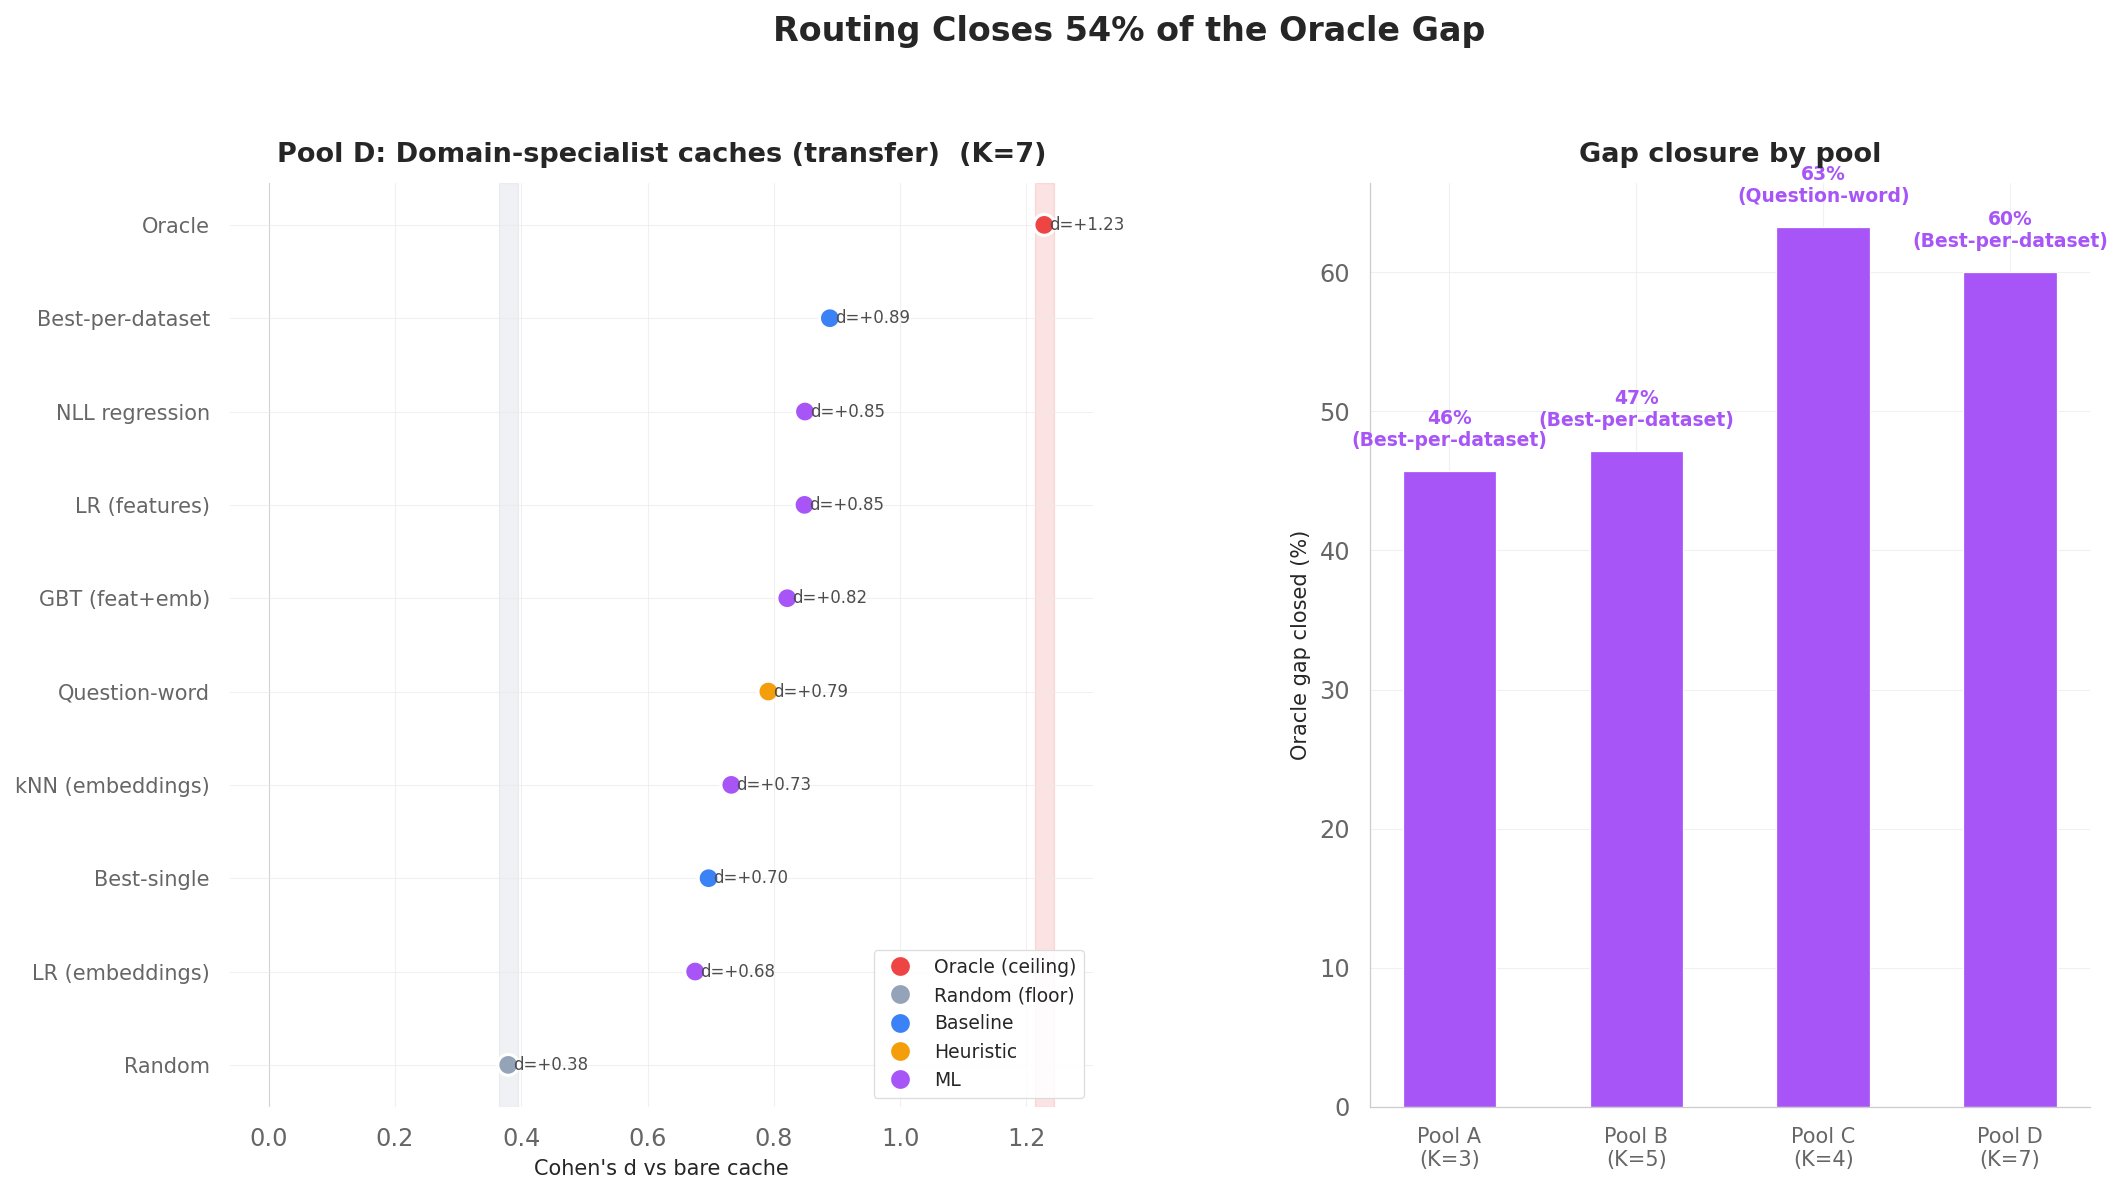

  Pool A (K=3): oracle=0.69, random=0.33, best=0.50 (Best-per-dataset), closure=45.7%
  Pool B (K=5): oracle=0.97, random=0.29, best=0.61 (Best-per-dataset), closure=47.1%
  Pool C (K=4): oracle=1.15, random=0.55, best=0.93 (Question-word), closure=63.3%
  Pool D (K=7): oracle=1.23, random=0.38, best=0.89 (Best-per-dataset), closure=60.0%
Saved slide_5_routing.png


In [6]:
# Slide 5: Routing Closes 30% of the Oracle Gap
# Left: dot plot of 10 strategies for Pool D
# Right: gap closure bars for all 4 pools
exp15_results = exp15_summary['results']
pools = exp15_summary['pools']
strategies = exp15_summary['strategies']

# --- Compute gap closure for all pools (needed for right panel + title) ---
gap_rows = []
for p_name in sorted(pools.keys()):
    oracle_key = f'{p_name}_Oracle'
    random_key = f'{p_name}_Random'
    if oracle_key in exp15_results and random_key in exp15_results:
        o_d = exp15_results[oracle_key]['d_vs_bare']
        r_d = exp15_results[random_key]['d_vs_bare']
        gap = o_d - r_d
        # Best non-ceiling/floor strategy
        best_d = max(
            (exp15_results[f'{p_name}_{s}']['d_vs_bare']
             for s in strategies
             if f'{p_name}_{s}' in exp15_results
             and exp15_results[f'{p_name}_{s}']['strategy_type'] not in ('ceiling', 'floor')),
            default=r_d)
        closure = (best_d - r_d) / gap if gap > 0 else 0
        # Find which strategy achieved best_d
        best_strat = 'N/A'
        for s in strategies:
            sk = f'{p_name}_{s}'
            if sk in exp15_results and exp15_results[sk]['strategy_type'] not in ('ceiling', 'floor'):
                if abs(exp15_results[sk]['d_vs_bare'] - best_d) < 1e-6:
                    best_strat = s
        gap_rows.append({
            'Pool': f'Pool {p_name}',
            'pool_key': p_name,
            'K': pools[p_name]['K'],
            'desc': pools[p_name]['description'],
            'Oracle d': o_d,
            'Random d': r_d,
            'Best d': best_d,
            'Best strategy': best_strat,
            'Gap': gap,
            'Closure': closure,
        })

gap_df = pd.DataFrame(gap_rows)
mean_closure = gap_df['Closure'].mean()

fig, (ax_dot, ax_gap) = plt.subplots(1, 2, figsize=(16, 8),
                                      gridspec_kw={'width_ratios': [1.2, 1], 'wspace': 0.35})

# --- Left panel: Pool D dot plot ---
pool_id = 'D'
pool_rows = []
for strat in strategies:
    key = f'{pool_id}_{strat}'
    if key in exp15_results:
        r = exp15_results[key]
        pool_rows.append({
            'Strategy': strat,
            'd_vs_bare': r['d_vs_bare'],
            'strategy_type': r['strategy_type'],
        })

pool_df = pd.DataFrame(pool_rows)
pool_df = pool_df.sort_values('d_vs_bare').reset_index(drop=True)

# Color by strategy type
type_colors = {
    'ceiling': '#EF4444',
    'floor': '#94A3B8',
    'baseline': '#3B82F6',
    'heuristic': '#F59E0B',
    'ml': '#A855F7',
}
dot_colors = [type_colors.get(row['strategy_type'], '#64748B')
              for _, row in pool_df.iterrows()]

y_dot = np.arange(len(pool_df))
ax_dot.scatter(pool_df['d_vs_bare'], y_dot, s=100, c=dot_colors, edgecolor='white',
               linewidth=1.5, zorder=3)

ax_dot.set_yticks(y_dot)
ax_dot.set_yticklabels(pool_df['Strategy'], fontsize=10)
ax_dot.axvline(0, color='.6', linewidth=0.5, zorder=0)
sns.despine(ax=ax_dot, left=True, bottom=True)

# Reference bands for Oracle and Random
oracle_d = pool_df[pool_df['Strategy'] == 'Oracle']['d_vs_bare'].values
random_d = pool_df[pool_df['Strategy'] == 'Random']['d_vs_bare'].values
if len(oracle_d) > 0:
    ax_dot.axvspan(oracle_d[0] - 0.015, oracle_d[0] + 0.015, alpha=0.15,
                   color='#EF4444', zorder=0)
if len(random_d) > 0:
    ax_dot.axvspan(random_d[0] - 0.015, random_d[0] + 0.015, alpha=0.15,
                   color='#94A3B8', zorder=0)

# Annotations
for i, (_, row) in enumerate(pool_df.iterrows()):
    ax_dot.text(row['d_vs_bare'] + 0.008, i, f"d={row['d_vs_bare']:+.2f}",
                va='center', ha='left', fontsize=8, color='.3')

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#EF4444',
           markersize=10, label='Oracle (ceiling)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#94A3B8',
           markersize=10, label='Random (floor)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3B82F6',
           markersize=10, label='Baseline'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#F59E0B',
           markersize=10, label='Heuristic'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#A855F7',
           markersize=10, label='ML'),
]
ax_dot.legend(handles=legend_elements, fontsize=9, framealpha=0.9, loc='lower right')
ax_dot.set_xlabel("Cohen's d vs bare cache", fontsize=10)
pool_info = pools[pool_id]
ax_dot.set_title(f'Pool {pool_id}: {pool_info["description"]}  (K={pool_info["K"]})',
                  fontsize=13, fontweight='bold', pad=10)

# --- Right panel: gap closure bars (vertical) ---
x_gap = np.arange(len(gap_df))
bar_colors = [GROUP_COLORS['soft']['accent']] * len(gap_df)
ax_gap.bar(x_gap, gap_df['Closure'] * 100, color=bar_colors, edgecolor='white',
           linewidth=0.6, width=0.5)

ax_gap.set_xticks(x_gap)
ax_gap.set_xticklabels([f"Pool {row['pool_key']}\n(K={row['K']})"
                         for _, row in gap_df.iterrows()], fontsize=10)
ax_gap.set_ylabel('Oracle gap closed (%)', fontsize=10)
ax_gap.set_title('Gap closure by pool', fontsize=13, fontweight='bold', pad=10)
sns.despine(ax=ax_gap)

# Annotate bars with percentage and best strategy
for i, (_, row) in enumerate(gap_df.iterrows()):
    ax_gap.text(i, row['Closure'] * 100 + 1.5,
                f"{row['Closure']:.0%}\n({row['Best strategy']})",
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                color=GROUP_COLORS['soft']['accent'])

fig.suptitle(f'Routing Closes {mean_closure:.0%} of the Oracle Gap',
             fontsize=16, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(CHART_DIR / 'slide_5_routing.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

# Print summary
for _, row in gap_df.iterrows():
    print(f"  Pool {row['pool_key']} (K={row['K']}): oracle={row['Oracle d']:.2f}, "
          f"random={row['Random d']:.2f}, best={row['Best d']:.2f} ({row['Best strategy']}), "
          f"closure={row['Closure']:.1%}")
print("Saved slide_5_routing.png")


In [7]:
# Summary
print("=" * 70)
print("ALL SLIDES GENERATED")
print("=" * 70)

import os
slide_files = sorted(f for f in os.listdir(CHART_DIR) if f.startswith('slide_'))
for f in slide_files:
    size = (CHART_DIR / f).stat().st_size / 1024
    print(f"  {f:<45} {size:>6.0f} KB")
print(f"\nTotal: {len(slide_files)} slide files in {CHART_DIR}")


ALL SLIDES GENERATED
  slide_1_every_prefix_helps.png                   147 KB
  slide_2_soft_prompt_ranking.png                  229 KB
  slide_3_init_comparison.png                      170 KB
  slide_4_transfer_matrix.png                      201 KB
  slide_5_routing.png                              158 KB

Total: 5 slide files in ../../../results/decoder_only/exp15/charts
